# Imports

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nhts = pd.read_csv("NHTS.csv")
ngsim = pd.read_csv("NGSIM.csv")

print(nhts.columns)
print(ngsim.columns)

Index(['household_id', 'census_division', 'census_region', 'driver_count',
       'household_income', 'household_size', 'household_workers', 'home_type',
       'household_location', 'number_adults_household',
       'vehicles_per_household', 'travel_date', 'travel_day', 'urban',
       'vehicle_type', 'hybrid', 'make', 'vehicle_age', 'vehicle_commercial',
       'vehicle_delivery', 'vehicle_rideshare', 'fuel_type', 'vehicle_year'],
      dtype='object')
Index(['Time', 'leader_position(m)', 'follower_position(m)',
       'leader_speed(m/s)', 'follower_speed(m/s)', 'leader_acc(m/s^2)',
       'follower_acc(m/s^2)', 'trajectory_number'],
      dtype='object')


# Load Data and Preview

In [55]:
import pandas as pd

nhts = pd.read_csv("NHTS.csv")
ngsim = pd.read_csv("NGSIM.csv")

print(nhts.columns)
print(ngsim.columns)

nhts.head()
ngsim.head()

print("\nNHTS Columns:\n", nhts.columns)
print("\nNGSIM Columns:\n", ngsim.columns)

Index(['household_id', 'census_division', 'census_region', 'driver_count',
       'household_income', 'household_size', 'household_workers', 'home_type',
       'household_location', 'number_adults_household',
       'vehicles_per_household', 'travel_date', 'travel_day', 'urban',
       'vehicle_type', 'hybrid', 'make', 'vehicle_age', 'vehicle_commercial',
       'vehicle_delivery', 'vehicle_rideshare', 'fuel_type', 'vehicle_year'],
      dtype='object')
Index(['Time', 'leader_position(m)', 'follower_position(m)',
       'leader_speed(m/s)', 'follower_speed(m/s)', 'leader_acc(m/s^2)',
       'follower_acc(m/s^2)', 'trajectory_number'],
      dtype='object')

NHTS Columns:
 Index(['household_id', 'census_division', 'census_region', 'driver_count',
       'household_income', 'household_size', 'household_workers', 'home_type',
       'household_location', 'number_adults_household',
       'vehicles_per_household', 'travel_date', 'travel_day', 'urban',
       'vehicle_type', 'hybrid', 'mak

# NHTS VISUALIZATION

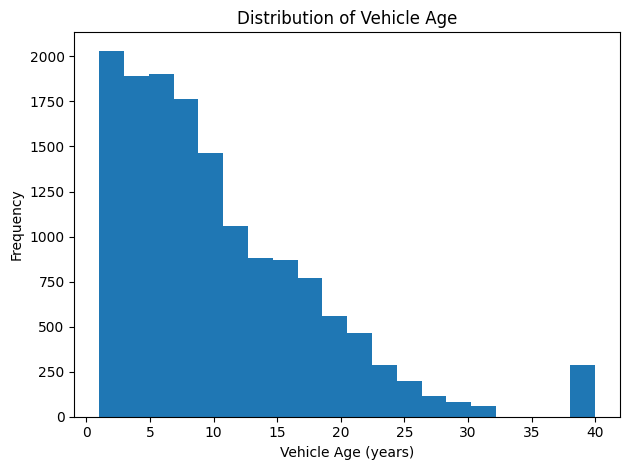

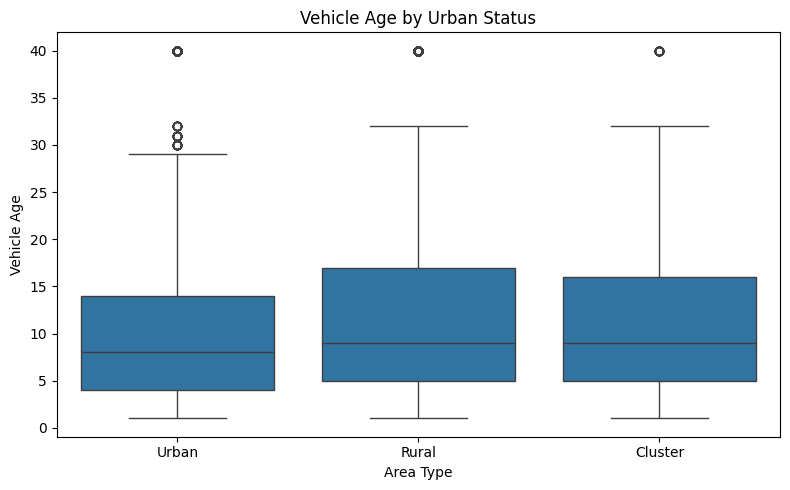

In [56]:
nhts["vehicle_age"] = pd.to_numeric(nhts["vehicle_age"], errors = "coerce")

plt.figure()
plt.hist(nhts["vehicle_age"].dropna(), bins = 20)

plt.title("Distribution of Vehicle Age")
plt.xlabel("Vehicle Age (years)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


urban_map = {
    "In an urban area": "Urban",
    "Not in an urban area": "Rural",
    "In an urban cluster": "Cluster",
    "Urban area surrounded by urban areas": "Urban Core"
}

nhts["urban_clean"] = nhts["urban"].map(urban_map)

# Plot
plt.figure(figsize=(8,5))
sns.boxplot(data=nhts, x="urban_clean", y="vehicle_age")

plt.title("Vehicle Age by Urban Status")
plt.xlabel("Area Type")
plt.ylabel("Vehicle Age")

plt.tight_layout()
plt.show()



# NGSIM Time Series

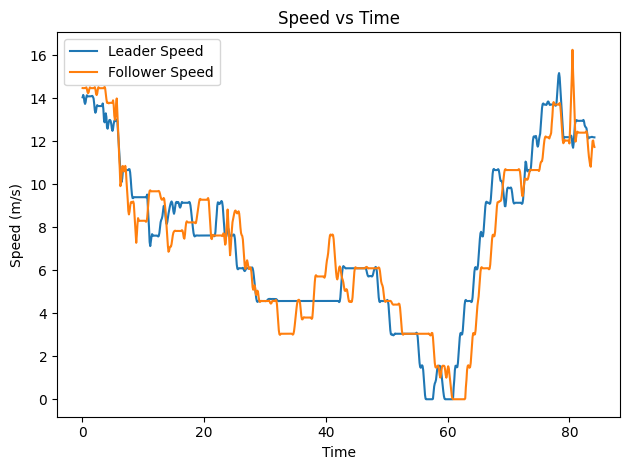

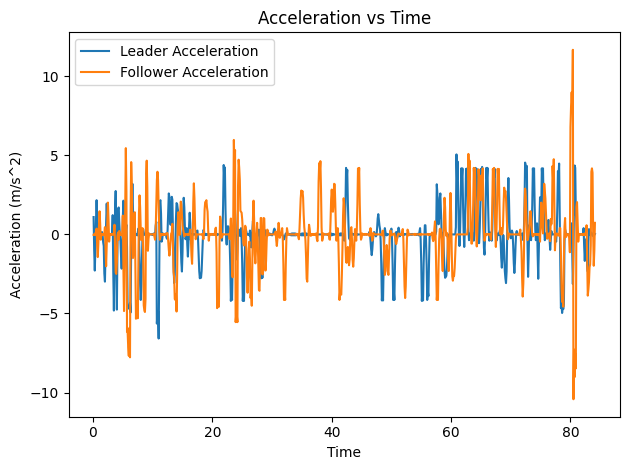

In [57]:
traj = ngsim[ngsim["trajectory_number"] ==1]

plt.figure()
plt.plot(traj["Time"], traj ["leader_speed(m/s)"], label = "Leader Speed")
plt.plot(traj["Time"], traj["follower_speed(m/s)"], label = "Follower Speed")

plt.title("Speed vs Time")
plt.xlabel("Time")
plt.ylabel("Speed (m/s)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(traj["Time"], traj["leader_acc(m/s^2)"], label = "Leader Acceleration")
plt.plot(traj["Time"], traj["follower_acc(m/s^2)"], label = "Follower Acceleration")

plt.title("Acceleration vs Time")
plt.xlabel("Time")
plt.ylabel("Acceleration (m/s^2)")
plt.legend()
plt.tight_layout()
plt.show()

# Part 2
**IDM Simulation**

**Defining Function**

In [4]:
#   v      : current speed of the follower vehicle (m/s)
#   s      : current gap distance between leader and follower (m)
#   delta_v : speed difference = follower speed - leader speed (m/s)
#   v0     : desired velocity (m/s)
#   s0     : minimum spacing (m)
#   T      : desired time headway (s)
#   a      : maximum acceleration (m/s^2)
#   b      : comfortable deceleration (m/s^2)
#   delta  : acceleration exponent

def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    # Step 1: Calculate the desired minimum gap s_star
    s_star = s0 + v * T + (v * delta_v)/(2*np.sqrt(a*b))

    # Make sure s_star is not negative
    s_star = max(s_star, s0)
    
    # Step 2: Calculate the acceleration using the IDM equation
    acceleration = a * (1 - (v/v0)**delta - (s_star/s)**2)

    return acceleration

**Set Up Simulation**

In [49]:
ngsim_data = pd.read_csv("NGSIM.csv")

trajectory_number = 1
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop=True)

time_data = data_subset['Time'].values
leader_position = data_subset['leader_position(m)'].values
leader_speed = data_subset['leader_speed(m/s)'].values
leader_acc = data_subset['leader_acc(m/s^2)'].values

dt= 0.05
v0 = 30  
s0 = 2     
T = 1
a_param = 3    
b = 3  
delta = 4


In [50]:
n_steps = len(time_data)       
sim_position = np.zeros(n_steps)       
sim_speed = np.zeros(n_steps)     
sim_acc = np.zeros(n_steps) 

sim_position[0] = data_subset['follower_position(m)'].values[0]      
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]


**Run Simulation**

In [51]:

for i in range(n_steps - 1): 
   
    gap = max(leader_position[i] - sim_position[i], 0.1)
    delta_v = sim_speed[i] - leader_speed[i]
   
    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a_param, b, delta)

    sim_speed[i+1] = max(sim_speed[i] + sim_acc[i] * dt,0)
    sim_position[i+1] = sim_position[i] + sim_speed[i] * dt

print("Simulation complete!")

Simulation complete!


**Visualization**

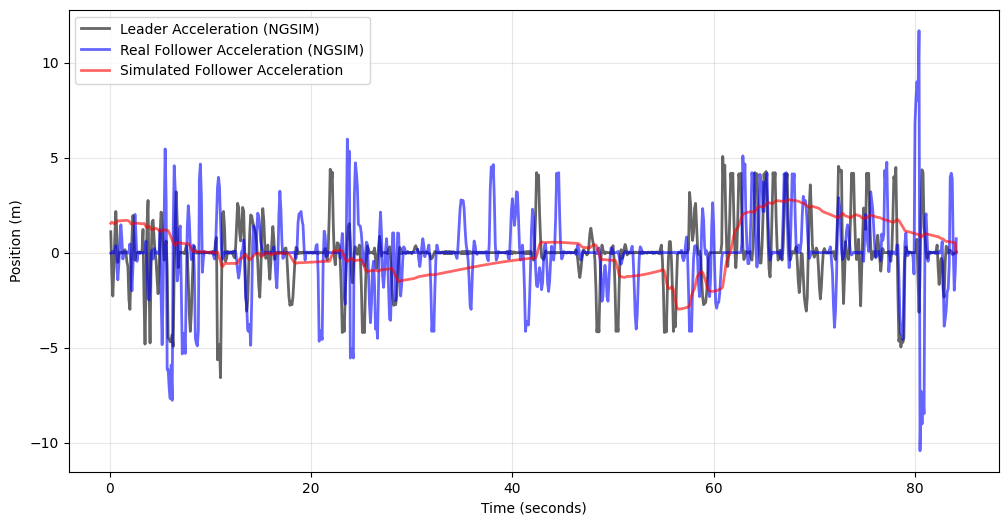

In [52]:

plt.figure(figsize = (12,6))
plt.plot(time_data, leader_acc, 'k-', linewidth = 2, label = 'Leader Acceleration (NGSIM)', alpha = 0.6)
plt.plot(time_data, data_subset['follower_acc(m/s^2)'].values, 'b-', linewidth = 2, label = 'Real Follower Acceleration (NGSIM)',alpha = 0.6)
plt.plot(time_data, sim_acc, 'r-', linewidth = 2, label = 'Simulated Follower Acceleration', alpha = 0.6)
plt.xlabel('Time (seconds)')
plt.ylabel('Position (m)')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()
           